In [1]:
import re #regular expression
import pandas as pd

In [3]:
f = open('WhatsApp Chat with Bca unofficial group.txt','r',encoding='utf-8')

In [5]:
data = f.read()

In [7]:
print(data) 

27/08/21, 12:18 pm - Messages and calls are end-to-end encrypted. No one outside of this chat, not even WhatsApp, can read or listen to them. Tap to learn more.
13/08/21, 1:42 pm - +91 75006 26555 created group "Bca unofficial group"
27/08/21, 12:18 pm - +91 88607 99610 joined using this group's invite link
27/08/21, 12:18 pm - +91 70423 70570: <Media omitted>
27/08/21, 12:18 pm - +91 81269 40942 joined using this group's invite link
27/08/21, 12:18 pm - +91 93196 82254 joined using this group's invite link
27/08/21, 12:18 pm - +91 89791 11760 joined using this group's invite link
27/08/21, 12:18 pm - +91 84497 55816: We boys have one too!
27/08/21, 12:18 pm - +91 96502 90236: Lele meme pe meme
27/08/21, 12:18 pm - +91 75418 01551 joined using this group's invite link
27/08/21, 12:18 pm - Dharma: 😂
27/08/21, 12:18 pm - +91 63875 32156: Oh ok
27/08/21, 12:18 pm - Chirag Pandat joined using this group's invite link
27/08/21, 12:18 pm - Shashank: Hai bhai
27/08/21, 12:19 pm - +91 96502 90

In [8]:
pattern = '\d{2}/\d{2}/\d{2}, \d{1,2}:\d{2}(?:\s?(?:AM|PM|am|pm))? -\s'

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Deepak\AppData\Local\Temp\ipykernel_14520\2934209901.py:1: SyntaxWarning: invalid escape sequence '\d'
  pattern = '\d{2}/\d{2}/\d{2}, \d{1,2}:\d{2}(?:\s?(?:AM|PM|am|pm))? -\s'


In [9]:
messages = re.split(pattern, data)[1:]
messages

['Messages and calls are end-to-end encrypted. No one outside of this chat, not even WhatsApp, can read or listen to them. Tap to learn more.\n',
 '+91 75006 26555 created group "Bca unofficial group"\n',
 "+91 88607 99610 joined using this group's invite link\n",
 '+91 70423 70570: <Media omitted>\n',
 "+91 81269 40942 joined using this group's invite link\n",
 "+91 93196 82254 joined using this group's invite link\n",
 "+91 89791 11760 joined using this group's invite link\n",
 '+91 84497 55816: We boys have one too!\n',
 '+91 96502 90236: Lele meme pe meme\n',
 "+91 75418 01551 joined using this group's invite link\n",
 'Dharma: 😂\n',
 '+91 63875 32156: Oh ok\n',
 "Chirag Pandat joined using this group's invite link\n",
 'Shashank: Hai bhai\n',
 '+91 96502 90236: College khulte hi sab palat jynge\n',
 'Sumit: Srishti yar mere reply nahi kiye 😂😂\n',
 '+91 96502 90236: 🙃\n',
 'Tushar: Bna hua h\n',
 '+91 63875 32156: Whomever have problem they can mute.\n',
 '+91 63875 32156: Simple\n

In [10]:
dates = re.findall(pattern,data)
dates =cleaned_dates = [date.replace('\u202f', '') for date in dates]
dates

['27/08/21, 12:18pm - ',
 '13/08/21, 1:42pm - ',
 '27/08/21, 12:18pm - ',
 '27/08/21, 12:18pm - ',
 '27/08/21, 12:18pm - ',
 '27/08/21, 12:18pm - ',
 '27/08/21, 12:18pm - ',
 '27/08/21, 12:18pm - ',
 '27/08/21, 12:18pm - ',
 '27/08/21, 12:18pm - ',
 '27/08/21, 12:18pm - ',
 '27/08/21, 12:18pm - ',
 '27/08/21, 12:18pm - ',
 '27/08/21, 12:18pm - ',
 '27/08/21, 12:19pm - ',
 '27/08/21, 12:19pm - ',
 '27/08/21, 12:19pm - ',
 '27/08/21, 12:19pm - ',
 '27/08/21, 12:19pm - ',
 '27/08/21, 12:19pm - ',
 '27/08/21, 12:19pm - ',
 '27/08/21, 12:19pm - ',
 '27/08/21, 12:19pm - ',
 '27/08/21, 12:19pm - ',
 '27/08/21, 12:20pm - ',
 '27/08/21, 12:20pm - ',
 '27/08/21, 12:20pm - ',
 '27/08/21, 12:20pm - ',
 '27/08/21, 12:20pm - ',
 '27/08/21, 12:20pm - ',
 '27/08/21, 12:20pm - ',
 '27/08/21, 12:20pm - ',
 '27/08/21, 12:20pm - ',
 '27/08/21, 12:20pm - ',
 '27/08/21, 12:20pm - ',
 '27/08/21, 12:21pm - ',
 '27/08/21, 12:21pm - ',
 '27/08/21, 12:21pm - ',
 '27/08/21, 12:21pm - ',
 '27/08/21, 12:21pm - ',
 

In [11]:
df = pd.DataFrame({'user_message':messages, 'message_dates':dates})

In [12]:
# Ensure a space before 'AM/PM' by replacing 'am' or 'pm' without space
df['message_dates'] = df['message_dates'].str.replace(r'([APap][Mm])', r' \1', regex=True)

# Now convert the dates with the corrected format
df['message_dates'] = pd.to_datetime(df['message_dates'], format='%d/%m/%y, %I:%M %p - ')

# Rename the column after converting it
df.rename(columns={'message_dates': 'date'}, inplace=True)

df.head()

,user_message,date
0,Messages and calls are end-to-end encrypted. N...,2021-08-27 12:18:00
1,"+91 75006 26555 created group ""Bca unofficial ...",2021-08-13 13:42:00
2,+91 88607 99610 joined using this group's invi...,2021-08-27 12:18:00
3,+91 70423 70570: <Media omitted>\n,2021-08-27 12:18:00
4,+91 81269 40942 joined using this group's invi...,2021-08-27 12:18:00


In [13]:
df.shape

(3362, 2)

In [14]:
users = []
messages = []
for message in df['user_message']:
    # Try to split the message into user and message content
    entry = re.split(r'([\w\W]+?):\s', message, maxsplit=1)
    
    # If the entry has a valid user and message
    if len(entry) > 2:
        users.append(entry[1])  # User name
        messages.append(entry[2])  # Message content
    else:
        users.append('group_notification')  # Handle system messages or group notifications
        messages.append(entry[0])  # The whole message is the notification

# Add the parsed users and messages into the DataFrame
df['user'] = users
df['message'] = messages

# Drop the original 'user_message' column
df.drop(columns=['user_message'], inplace=True)

df.head()


,date,user,message
0,2021-08-27 12:18:00,group_notification,Messages and calls are end-to-end encrypted. N...
1,2021-08-13 13:42:00,group_notification,"+91 75006 26555 created group ""Bca unofficial ..."
2,2021-08-27 12:18:00,group_notification,+91 88607 99610 joined using this group's invi...
3,2021-08-27 12:18:00,+91 70423 70570,<Media omitted>\n
4,2021-08-27 12:18:00,group_notification,+91 81269 40942 joined using this group's invi...


In [15]:
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month_name()
df['day']=df['date'].dt.day
df['minute']=df['date'].dt.minute

In [16]:
df.head()

,date,user,message,year,month,day,minute
0,2021-08-27 12:18:00,group_notification,Messages and calls are end-to-end encrypted. N...,2021,August,27,18
1,2021-08-13 13:42:00,group_notification,"+91 75006 26555 created group ""Bca unofficial ...",2021,August,13,42
2,2021-08-27 12:18:00,group_notification,+91 88607 99610 joined using this group's invi...,2021,August,27,18
3,2021-08-27 12:18:00,+91 70423 70570,<Media omitted>\n,2021,August,27,18
4,2021-08-27 12:18:00,group_notification,+91 81269 40942 joined using this group's invi...,2021,August,27,18


In [17]:
words=[]
for message in df['message']:
    words.extend(message.split())

In [18]:
len(words)

17501

In [19]:
df[df['message'] == "<Media omitted>\n"]

,date,user,message,year,month,day,minute
3,2021-08-27 12:18:00,+91 70423 70570,<Media omitted>\n,2021,August,27,18
54,2021-08-27 12:22:00,+91 70423 70570,<Media omitted>\n,2021,August,27,22
56,2021-08-27 12:22:00,+91 84497 55816,<Media omitted>\n,2021,August,27,22
58,2021-08-27 12:22:00,Deepak Chander🦁,<Media omitted>\n,2021,August,27,22
60,2021-08-27 12:23:00,+91 70423 70570,<Media omitted>\n,2021,August,27,23
...,...,...,...,...,...,...,...
3335,2023-01-09 18:33:00,Jitin,<Media omitted>\n,2023,January,9,33
3338,2023-03-12 09:56:00,+91 93554 41332,<Media omitted>\n,2023,March,12,56
3344,2023-03-27 19:07:00,+91 84497 55816,<Media omitted>\n,2023,March,27,7
3349,2023-04-20 12:56:00,Saurabh,<Media omitted>\n,2023,April,20,56


In [22]:
!pip install urlextract

In [23]:
from urlextract import URLExtract

extractor = URLExtract()
urls = extractor.find_urls("Text with URLs. Let's have URL janlipovsky.cz as an example google.com, http://facebook.com, ftp://url.in.")

In [24]:
y = []
for mesage in df['message']:
    y.extend(extractor.find_urls(message))

In [25]:
len(y)

3362

In [27]:
x = df['user'].value_counts().head()

C:\Users\Deepak\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129409 (\N{LION FACE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


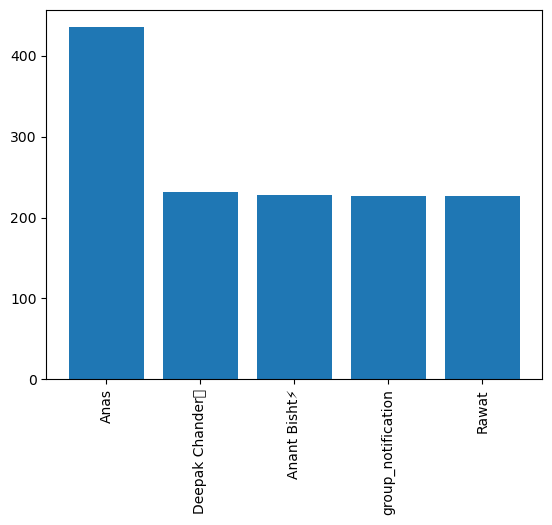

In [28]:
import matplotlib.pyplot as plt
name = x.index
counts = x.values
plt.bar(name, counts)
plt.xticks(rotation='vertical')
plt.show()

In [29]:
round((df['user'].value_counts()/df.shape[0])*100,2).reset_index().rename(columns={'user':'name','count':'percent'})

,name,percent
0,Anas,12.94
1,Deepak Chander🦁,6.90
2,Anant Bisht⚡️,6.78
3,group_notification,6.75
4,Rawat,6.75
...,...,...
76,Tanisha,0.03
77,+91 99277 27699,0.03
78,+91 88820 39556,0.03
79,Chirag Pandat,0.03


In [30]:
words = []
for message in df['message']:
    words.extend(message.split())

In [34]:
from collections import Counter
pd.DataFrame(Counter(words).most_common(20))

,0,1
0,(file,336
1,attached),336
2,<Media,287
3,omitted>,287
4,to,255
5,h,239
6,+91,166
7,the,157
8,hai,150
9,bhai,134


In [36]:
temp = df[df['user'] != 'group_notification']
temp = temp[temp['message'] != '<Media omitted>\n']

In [42]:
temp

,date,user,message,year,month,day,minute
7,2021-08-27 12:18:00,+91 84497 55816,We boys have one too!\n,2021,August,27,18
8,2021-08-27 12:18:00,+91 96502 90236,Lele meme pe meme\n,2021,August,27,18
10,2021-08-27 12:18:00,Dharma,😂\n,2021,August,27,18
11,2021-08-27 12:18:00,+91 63875 32156,Oh ok\n,2021,August,27,18
13,2021-08-27 12:18:00,Shashank,Hai bhai\n,2021,August,27,18
...,...,...,...,...,...,...,...
3357,2023-07-24 04:15:00,Anant Bisht⚡️,This message was deleted\n,2023,July,24,15
3358,2023-07-27 02:55:00,+91 83838 84589,This message was deleted\n,2023,July,27,55
3359,2023-07-27 17:09:00,Hemika,This message was deleted\n,2023,July,27,9
3360,2023-07-27 17:09:00,Hemika,This message was deleted\n,2023,July,27,9


In [44]:
f = open('stop_hinglish.txt','r')
stop_words = f.read()
print(stop_words)

.
..
...
?
-
--
1
2
3
4
5
6
7
8
9
0
a
aadi
aaj
aap
aapne
aata
aati
aaya
aaye
ab
abbe
abbey
abe
abhi
able
about
above
accha
according
accordingly
acha
achcha
across
actually
after
afterwards
again
against
agar
ain
aint
ain't
aisa
aise
aisi
alag
all
allow
allows
almost
alone
along
already
also
although
always
am
among
amongst
an
and
andar
another
any
anybody
anyhow
anyone
anything
anyway
anyways
anywhere
ap
apan
apart
apna
apnaa
apne
apni
appear
are
aren
arent
aren't
around
arre
as
aside
ask
asking
at
aur
avum
aya
aye
baad
baar
bad
bahut
bana
banae
banai
banao
banaya
banaye
banayi
banda
bande
bandi
bane
bani
bas
bata
batao
bc
be
became
because
become
becomes
becoming
been
before
beforehand
behind
being
below
beside
besides
best
better
between
beyond
bhai
bheetar
bhi
bhitar
bht
bilkul
bohot
bol
bola
bole
boli
bolo
bolta
bolte
bolti
both
brief
bro
btw
but
by
came
can
cannot
cant
can't
cause
causes
certain
certainly
chahiye
chaiye
chal
chalega
chhaiye
clearly
c'mon
com
come
comes
could
coul

In [45]:
words = []
for message in temp['message']:
    for word in message.lower().split():
        if word not in stop_words:
            words.append(word)

In [46]:
words

['boys',
 'too!',
 'lele',
 'meme',
 'meme',
 '😂',
 'college',
 'khulte',
 'palat',
 'jynge',
 'srishti',
 'yar',
 'reply',
 '😂😂',
 '🙃',
 'bna',
 'whomever',
 'problem',
 'mute.',
 'simple',
 'abee',
 'kasa',
 'gyi',
 'sumit',
 '😏',
 'where?',
 'song',
 'sunega',
 'class',
 '🤣😂',
 '<media',
 'omitted>',
 'ispe',
 '😂😂',
 'sunao',
 'baba',
 'chla',
 '😂',
 'chala',
 'koisa',
 'zyda',
 'dhyan',
 'jara',
 'bja',
 'sumit',
 'sunayega',
 'suna',
 '😅',
 'musk',
 'thora',
 'sabar',
 'kijiye!',
 'dhere',
 'dhere',
 'sb',
 '😂',
 'message',
 'deleted',
 'brown',
 'munda',
 'bajna',
 'deh',
 'yar',
 'kaishe',
 '😂',
 '😂',
 '😂😂😂',
 '🤣🤣',
 'haaaa',
 'baba',
 'gana',
 'bajte',
 'rehna',
 '😂😂😂😂😂😂😂😂',
 'siddhu',
 'gane',
 'bjara',
 'yash',
 'manja😂😂🤣🤣',
 'maanush',
 'gana',
 'bja',
 '😂😂😂😂',
 'gana',
 'mute',
 'krlo',
 'zyda',
 'hojyga',
 'elon',
 'musk🤣🤣',
 'elon',
 'musk',
 'reveal',
 'krega',
 'bta',
 'hbu',
 'kesaa',
 '😂🤣',
 'mst🤣🤣',
 'kra',
 'song',
 'suna',
 'class',
 '☹️',
 'mja',
 'gya',
 'elon',


In [47]:
from collections import Counter
pd.DataFrame(Counter(words).most_common(20))

,0,1
0,(file,336
1,attached),336
2,😂,124
3,😂😂,96
4,message,76
5,deleted,74
6,🥲,60
7,😂😂😂,39
8,🤣🤣,38
9,college,33


In [65]:
df['month_num'] = df['date'].dt.month

In [67]:
df

,date,user,message,year,month,day,minute,month_num
0,2021-08-27 12:18:00,group_notification,Messages and calls are end-to-end encrypted. N...,2021,August,27,18,8
1,2021-08-13 13:42:00,group_notification,"+91 75006 26555 created group ""Bca unofficial ...",2021,August,13,42,8
2,2021-08-27 12:18:00,group_notification,+91 88607 99610 joined using this group's invi...,2021,August,27,18,8
3,2021-08-27 12:18:00,+91 70423 70570,<Media omitted>\n,2021,August,27,18,8
4,2021-08-27 12:18:00,group_notification,+91 81269 40942 joined using this group's invi...,2021,August,27,18,8
...,...,...,...,...,...,...,...,...
3357,2023-07-24 04:15:00,Anant Bisht⚡️,This message was deleted\n,2023,July,24,15,7
3358,2023-07-27 02:55:00,+91 83838 84589,This message was deleted\n,2023,July,27,55,7
3359,2023-07-27 17:09:00,Hemika,This message was deleted\n,2023,July,27,9,7
3360,2023-07-27 17:09:00,Hemika,This message was deleted\n,2023,July,27,9,7


In [69]:
timeline = df.groupby(['year','month_num','month']).count()['message'].reset_index()

In [71]:
timeline

,year,month_num,month,message
0,2021,8,August,724
1,2021,9,September,2103
2,2021,10,October,210
3,2021,11,November,36
4,2021,12,December,42
5,2022,1,January,21
6,2022,2,February,4
7,2022,3,March,7
8,2022,4,April,23
9,2022,5,May,9


In [73]:
time=[]
for i in range(timeline.shape[0]):
    time.append(timeline['month'][i] + "-" + str(timeline['year'][i]))

In [75]:
time

['August-2021',
 'September-2021',
 'October-2021',
 'November-2021',
 'December-2021',
 'January-2022',
 'February-2022',
 'March-2022',
 'April-2022',
 'May-2022',
 'June-2022',
 'July-2022',
 'October-2022',
 'November-2022',
 'December-2022',
 'January-2023',
 'March-2023',
 'April-2023',
 'May-2023',
 'June-2023',
 'July-2023',
 'August-2023']

In [77]:
timeline['time']=time

In [79]:
timeline

,year,month_num,month,message,time
0,2021,8,August,724,August-2021
1,2021,9,September,2103,September-2021
2,2021,10,October,210,October-2021
3,2021,11,November,36,November-2021
4,2021,12,December,42,December-2021
5,2022,1,January,21,January-2022
6,2022,2,February,4,February-2022
7,2022,3,March,7,March-2022
8,2022,4,April,23,April-2022
9,2022,5,May,9,May-2022


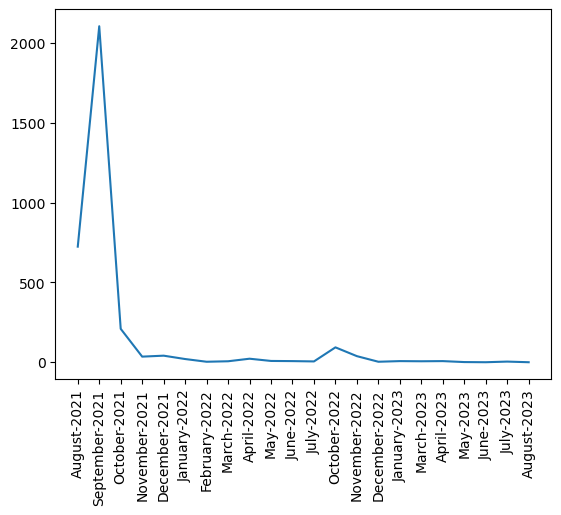

In [81]:
plt.plot(timeline['time'],timeline['message'])
plt.xticks(rotation='vertical')
plt.show()

In [85]:
df['only_date']=df['date'].dt.date

In [91]:
daily_timeline = df.groupby('only_date').count()['message'].reset_index()

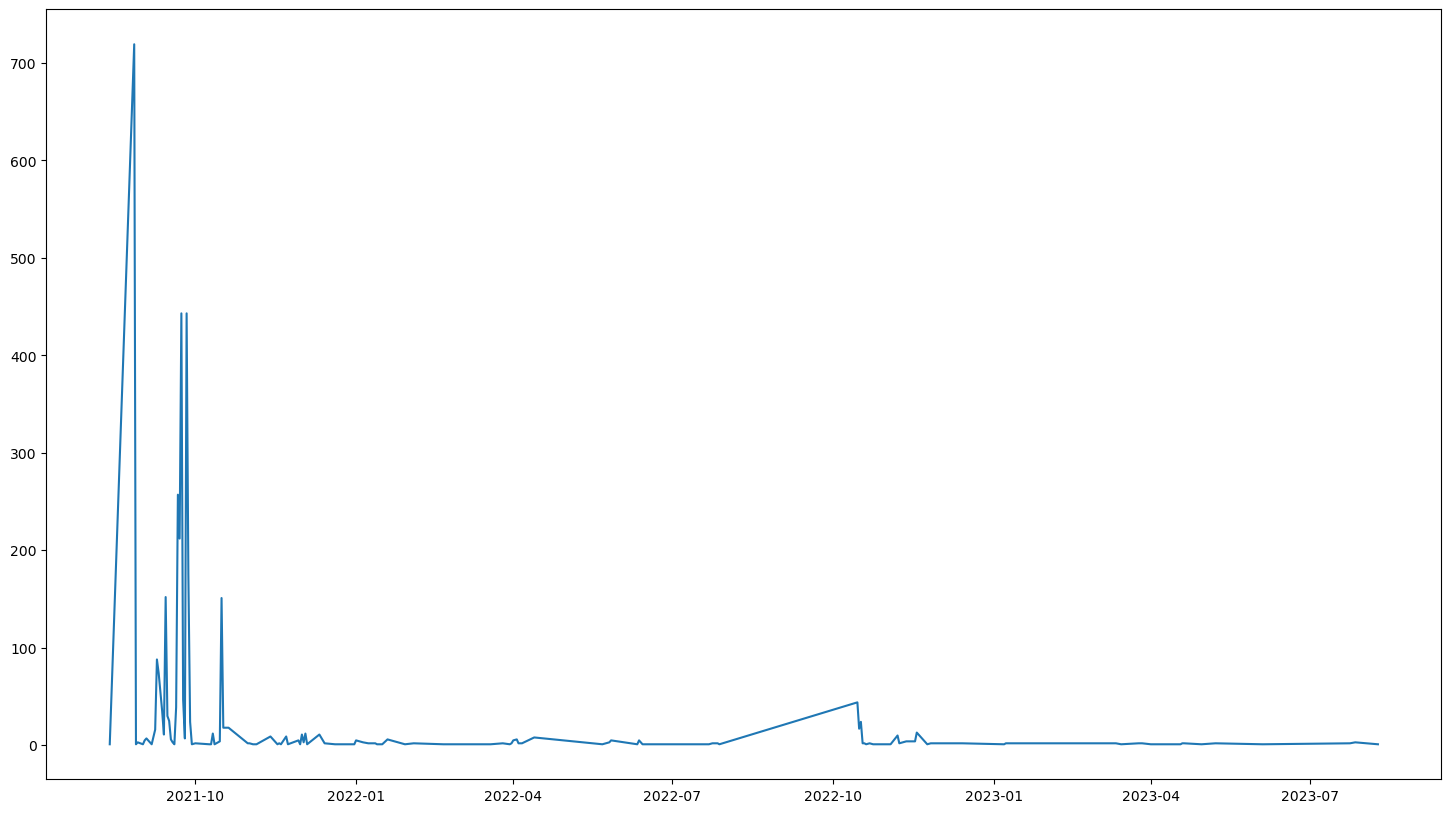

In [97]:
plt.figure(figsize=(18,10))
plt.plot(daily_timeline['only_date'],daily_timeline['message'])

In [101]:
df['day_name']=df['date'].dt.day_name()

In [105]:
df['day_name'].value_counts()

day_name
Friday       901
Thursday     589
Sunday       546
Tuesday      450
Wednesday    323
Monday       300
Saturday     253
Name: count, dtype: int64